### Navigation in the folder system to find the right videos and sort them

In [74]:
import numpy as np 
import os
import pandas as pd

In [101]:
def is_video(filename : str) -> bool : 
    video_extensions = (".avi", ".mp4")
    return filename.lower().endswith(video_extensions)


def sort_componants(components : list) -> pd.DataFrame :
    categorized = {
        "number": [],
        "alpha": [],
        "alphanumeric": [],
        "special": [],
        "mixed": []
    }

    for comp in components:

        if comp.isdigit():
            categorized["number"].append(comp)

        elif comp.isalpha():
            categorized["alpha"].append(comp)

        elif comp.isalnum():
            categorized["alphanumeric"].append(comp)

        else:
            categorized["mixed"].append(comp)

    df = dict_to_df(categorized)

    return df



def decompose_video_name(filename : str) : 

    # remove the format of the name (.avi, .mp4 ...)
    name, format = os.path.splitext(filename)
    componants = name.split("_")
    
    return componants


def dict_to_df(dict : dict) : 
    
     # Find the maximum length of the columns
    max_len = max(len(lst) for lst in dict.values())

    for key in dict:
        while len(dict[key]) < max_len:
            dict[key].append("") ## empty slots to match all columns size

    return pd.DataFrame(dict)

In [102]:
rootdir = "/media/filer2/T4b/Datasets/Rats/Photron_Video/Raphael2024"
# rootdir = "/media/filer2/T4b/UserFolders/Raphael/ProcessedData/DOPAMOVE/Raphael"

all_componants = set()

for root, dirs, files in os.walk(rootdir):
    for name in files : 
        if is_video(name) :
            comp = decompose_video_name(name)
            all_componants.update(comp)


sorted_componants = sort_componants(all_componants)
sorted_componants


,number,alpha,alphanumeric,special,mixed
0,20240702,contra,ContiMT300L1L2,,"0,75mW"
1,20240626,Rat,C001H001S0006,,L2-40
2,20240620,ContraCHR,C001H001S0005,,L1-60
3,20240526,LeftHemi,C001H002S0006,,#519LeftHanded
4,20240530,FiberContra,L1,,"2,5mW"
5,20240712,LeftHemiCHR,s2,,#525Ambidexter
6,20240705,BilateralCHR,C001H002S0004,,#527RightHanded
7,20240528,IpsiHemi,C001H001S0003,,#521RightHanded
8,20240721,NOstim,L1L2,,#529
9,20240703,LeftHemiCTRL,BetaMT300,,#531LeftHanded


### Sort files by their quategories

filename    | rats      | condition | stimulation location | task           | rat handedness | session | view |
--------    | -------   | -------   |--------              | -------        | -------        | ------- |----- |
...         |  CHRIMSON | NOstim    | LeftHemi             | onlyL1LeftHand | Ambidexter     | 1       | 1    |
...         | CTRL      | Conti     | RightHemi            | L1L2           | LeftHanded     | 2       | 2    |
...         | Unkown    | Beta      | Bilateral            | onlyL2         | RightHanded    | 3       |      |
...         |           |           | Ipsi                 | onlyL1         |                | ...     |      |
...         |           |           | Contra               | L1L25050       |                |         |      |
...         |           |           |                      | L1L26040       |                |         |      |
...         |           |           |                      | L1             |                |         |      |
...         |           |           |                      | L2             |                |         |      |


In [ ]:
import pandas as pd
import re

def extract_type(input : str, regex : str) -> str : 
    match = re.search(regex, input)

    if match : 
        return match.group(0)
    
    return None


def classify_video(filename: str, videos: list) -> None:
    name_comp = decompose_video_name(filename)

    result = {
        "rat_type": "Unknown",
        "condition": "Unknown",
        "stim_location": "Unknown",
        "task": "Unknown",
        "handedness": "Unknown",
        "session": "Unknown",
        "view": "Unknown",
    }

    for token in name_comp:

        if result["rat_type"] == "Unknown":
            match = extract_type(token, r"(CTRL|CHR)")
            if match:
                result["rat_type"] = match

        if result["condition"] == "Unknown":
            match = extract_type(token, r"(Conti|NOstim|Beta)")
            if match:
                result["condition"] = match

        if result["stim_location"] == "Unknown":
            match = extract_type(token, r"(LeftHemi|RightHemi|Ipsi|ipsi|Bilateral|Contra)")
            if match:
                result["stim_location"] = match

        if result["handedness"] == "Unknown":
            match = extract_type(token, r"(Ambidexter|LeftHanded|RightHanded)")
            if match:
                result["handedness"] = match

        if result["session"] == "Unknown":
            match = extract_type(token, r"S\d+")
            if match:
                result["session"] = match

        if result["view"] == "Unknown":
            match = extract_type(token, r"H\d+")
            if match:
                result["view"] = match

        if result["task"] == "Unknown":
            match = extract_type(token, r"H\d+")
            if match:
                result["view"] = match

        if result["task"] == "Unknown" and token in [
            "onlyL1LeftHand", "onlyL2", "onlyL1",
            "L1", "L2", "L1L2", "L1L26040", "L1L25050", "L1-60" # je rajoute pas L2-40 car va avec L1-60
        ]:
            result["task"] = token

    videos.append({
        "filename": filename,
        **result
    })


In [104]:
ct_video = 0
sorted_videos = []
for root, dirs, files in os.walk(rootdir):
    for name in files:
        if is_video(name):
            classify_video(os.path.join(root, name), sorted_videos)
            ct_video += 1


df = pd.DataFrame(sorted_videos)
print(f"Nombre total de vidéo {ct_video}")
print(f"Nombre de video collecté : {len(df)}")
df


Nombre total de vidéo 648
Nombre de video collecté : 648


,filename,rat_type,condition,stim_location,task,handedness,session,view
0,/media/filer2/T4b/Datasets/Rats/Photron_Video/...,CHR,Beta,LeftHemi,onlyL1LeftHand,Ambidexter,S0001,H001
1,/media/filer2/T4b/Datasets/Rats/Photron_Video/...,CHR,Beta,LeftHemi,onlyL1LeftHand,Ambidexter,S0002,H001
2,/media/filer2/T4b/Datasets/Rats/Photron_Video/...,CHR,Beta,LeftHemi,onlyL1LeftHand,Ambidexter,S0003,H001
3,/media/filer2/T4b/Datasets/Rats/Photron_Video/...,CHR,Beta,LeftHemi,onlyL1LeftHand,Ambidexter,S0001,H002
4,/media/filer2/T4b/Datasets/Rats/Photron_Video/...,CHR,Beta,LeftHemi,onlyL1LeftHand,Ambidexter,S0002,H002
...,...,...,...,...,...,...,...,...
643,/media/filer2/T4b/Datasets/Rats/Photron_Video/...,CHR,Conti,LeftHemi,L1L25050,LeftHanded,S0001,H002
644,/media/filer2/T4b/Datasets/Rats/Photron_Video/...,CHR,Conti,LeftHemi,L1L25050,LeftHanded,S0002,H002
645,/media/filer2/T4b/Datasets/Rats/Photron_Video/...,CHR,Conti,LeftHemi,L1L25050,LeftHanded,S0003,H002
646,/media/filer2/T4b/Datasets/Rats/Photron_Video/...,CHR,Conti,LeftHemi,L1L25050,LeftHanded,S0004,H002


In [105]:
# save as cvs
df.to_csv("videos_list_sorted.csv")

**Exemple de recherche par categorie**  :

In [106]:
CHR = df[df["rat_type"] == "CHRIMSON"]
CHR.groupby(["rat_type", "condition"]).size()


Series([], dtype: int64)

In [107]:
# filtration of the KO rat
no_KO_rats_df = df[df["rat_type"] != "Unknown"]
no_KO_rats_df.to_csv("no_KO_video_list.csv")

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

def display_count_per_rat_condition(df : pd.DataFrame, condition : str) -> None :

    counts = (
        df.groupby(["rat_type", condition])
        .size()
        .reset_index(name="count")
    )


    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=counts,
        x="rat_type",
        y="count",
        hue=condition
    )
    
    for container in ax.containers:
        ax.bar_label(container)

    plt.xlabel("Rat type")
    plt.ylabel("Number of videos")
    plt.title(f"Video count by rat type and {condition}")
    plt.savefig(os.path.join("figures", f"No_KO_Video_count_per_{condition}"))

    plt.tight_layout()
    plt.show()


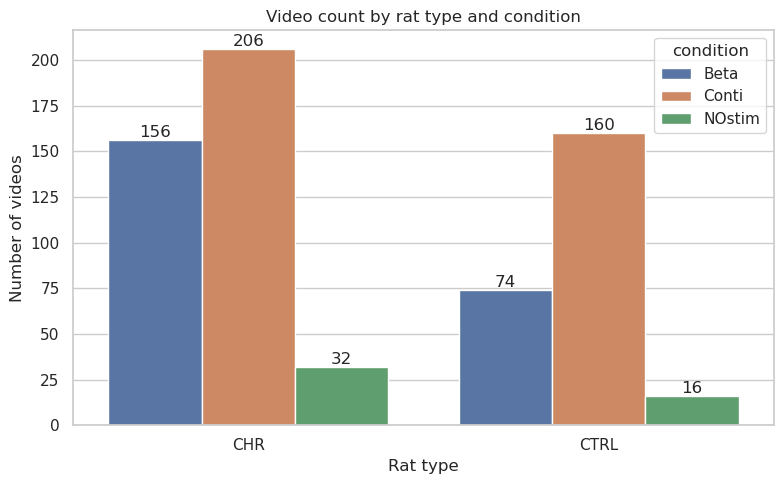

In [109]:
display_count_per_rat_condition(no_KO_rats_df, "condition")

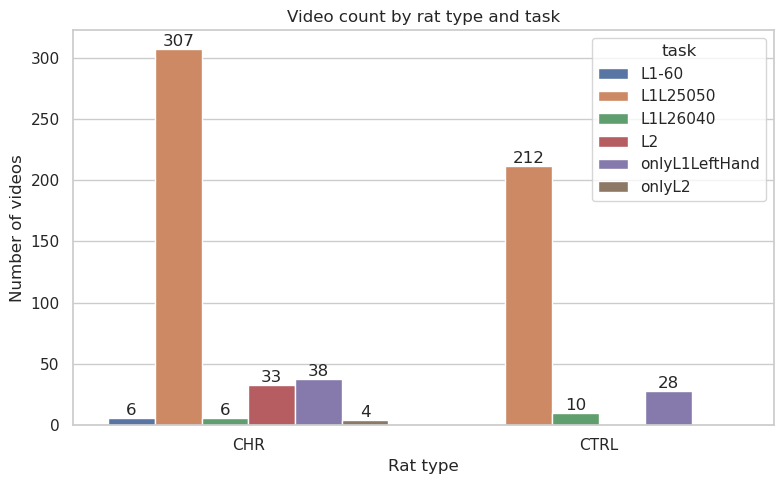

In [110]:
display_count_per_rat_condition(no_KO_rats_df, "task")

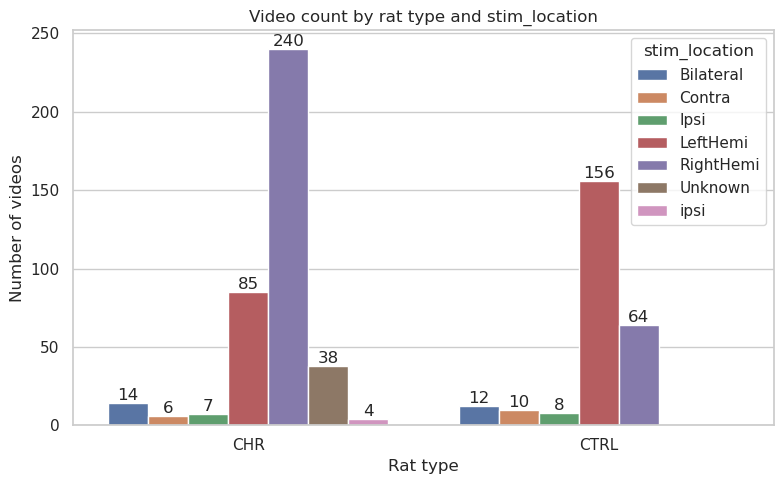

In [111]:
display_count_per_rat_condition(no_KO_rats_df, "stim_location")

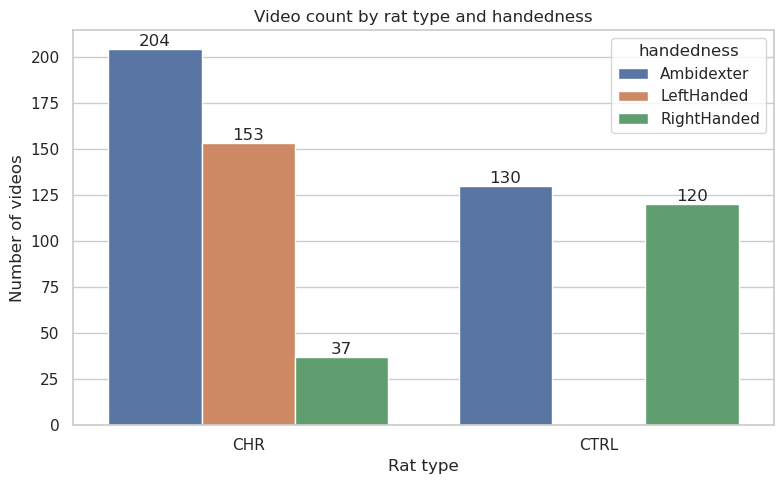

In [112]:
display_count_per_rat_condition(no_KO_rats_df, "handedness")

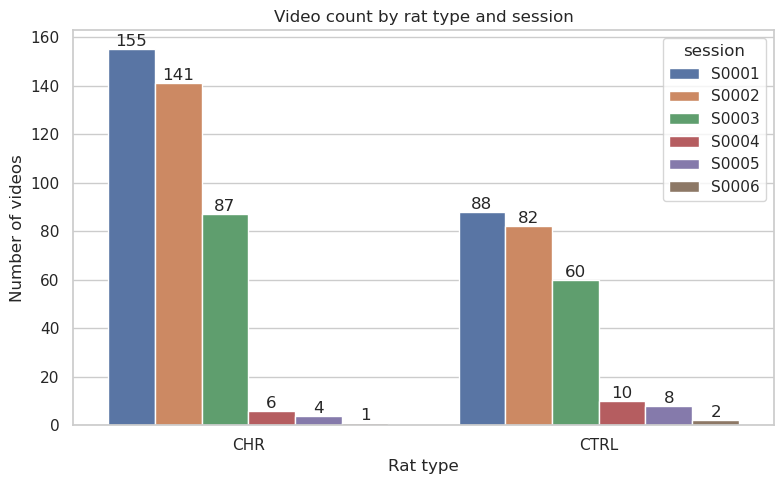

In [113]:
display_count_per_rat_condition(no_KO_rats_df, "session")

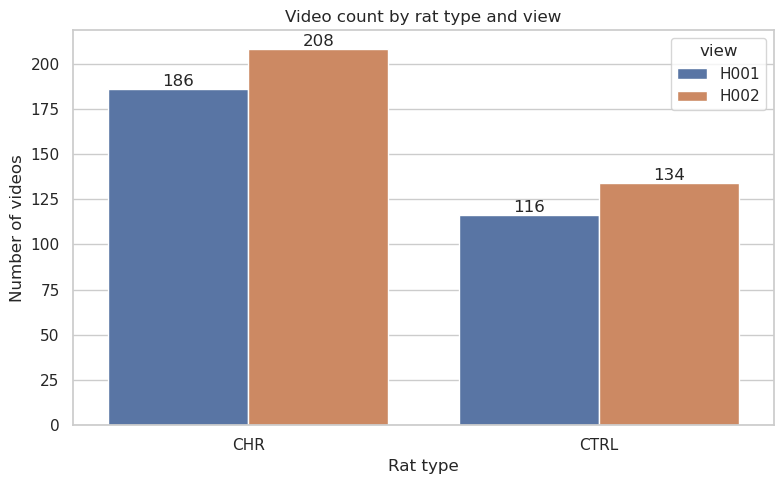

In [114]:
display_count_per_rat_condition(no_KO_rats_df, "view")